In [1]:
import os
import json
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from PIL import Image

print("TensorFlow:", tf.__version__)
print("✅ All libraries imported!")

TensorFlow: 2.21.0
✅ All libraries imported!


In [2]:
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 20
DATASET_DIR = "dataset"
CLASSES     = ["mouse", "keyboard", "phone", "charger"]
NUM_CLASSES = len(CLASSES)

print(f"Classes    : {CLASSES}")
print(f"Num Classes: {NUM_CLASSES}")
print(f"Image Size : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size : {BATCH_SIZE}")
print(f"Max Epochs : {EPOCHS}")
print("✅ Configuration set!")

Classes    : ['mouse', 'keyboard', 'phone', 'charger']
Num Classes: 4
Image Size : 224x224
Batch Size : 32
Max Epochs : 20
✅ Configuration set!


In [3]:
def get_hash(filepath):
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def clean_folder(folder_path, class_name):
    print(f"\nCleaning: {class_name.upper()}")
    files       = os.listdir(folder_path)
    print(f"  Before: {len(files)} images")
    seen_hashes = set()
    removed_dup = 0
    removed_cor = 0
    kept        = 0
    for filename in files:
        filepath = os.path.join(folder_path, filename)
        if not filename.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp')):
            os.remove(filepath)
            continue
        try:
            img = Image.open(filepath)
            img.verify()
        except:
            os.remove(filepath)
            removed_cor += 1
            continue
        try:
            img  = Image.open(filepath)
            img  = img.convert("RGB")
            w, h = img.size
            if w < 50 or h < 50:
                os.remove(filepath)
                removed_cor += 1
                continue
        except:
            os.remove(filepath)
            removed_cor += 1
            continue
        img_hash = get_hash(filepath)
        if img_hash in seen_hashes:
            os.remove(filepath)
            removed_dup += 1
            continue
        seen_hashes.add(img_hash)
        kept += 1
    print(f"  Corrupt removed  : {removed_cor}")
    print(f"  Duplicate removed: {removed_dup}")
    print(f"  Clean images kept: {kept}")
    return kept

for class_name in CLASSES:
    clean_folder(f"dataset/{class_name}", class_name)

print("\n✅ Dataset cleaned!")


Cleaning: MOUSE
  Before: 300 images
  Corrupt removed  : 0
  Duplicate removed: 164
  Clean images kept: 136

Cleaning: KEYBOARD
  Before: 300 images


C:\ProgramData\anaconda3\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Corrupt removed  : 0
  Duplicate removed: 192
  Clean images kept: 108

Cleaning: PHONE
  Before: 300 images
  Corrupt removed  : 0
  Duplicate removed: 245
  Clean images kept: 55

Cleaning: CHARGER
  Before: 300 images
  Corrupt removed  : 0
  Duplicate removed: 182
  Clean images kept: 118

✅ Dataset cleaned!


In [4]:
for class_name in CLASSES:
    folder = f"dataset/{class_name}"
    files  = sorted(os.listdir(folder))
    
    for i, filename in enumerate(files):
        old_path = os.path.join(folder, filename)
        tmp_path = os.path.join(folder, f"tmp_{i+1:04d}.jpg")
        os.rename(old_path, tmp_path)
    
    tmp_files = sorted(os.listdir(folder))
    for i, filename in enumerate(tmp_files):
        old_path = os.path.join(folder, filename)
        new_path = os.path.join(folder, f"{class_name}_{i+1:04d}.jpg")
        os.rename(old_path, new_path)
    
    count = len(os.listdir(folder))
    print(f"{class_name:12} : {count} images renamed")

print("\n✅ All images renamed!")

mouse        : 150 images renamed
keyboard     : 150 images renamed
phone        : 150 images renamed
charger      : 150 images renamed

✅ All images renamed!


In [5]:
train_datagen = ImageDataGenerator(
    rescale           = 1./255,
    rotation_range    = 20,
    width_shift_range = 0.2,
    height_shift_range= 0.2,
    horizontal_flip   = True,
    zoom_range        = 0.2,
    validation_split  = 0.2
)

train_data = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = "categorical",
    subset       = "training"
)

val_data = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = "categorical",
    subset       = "validation"
)

print(f"Training images  : {train_data.samples}")
print(f"Validation images: {val_data.samples}")
print(f"Class map        : {train_data.class_indices}")
print("\n✅ Dataset loaded!")

Found 480 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Training images  : 480
Validation images: 120
Class map        : {'charger': 0, 'keyboard': 1, 'mouse': 2, 'phone': 3}

✅ Dataset loaded!


In [6]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = (IMG_SIZE, IMG_SIZE, 3),
    include_top = False,
    weights     = "imagenet"
)
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)

model.summary()
print("\n✅ Model built!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,980 (9.24 MB)

 Trainable params: 164,740 (643.52 KB)

 Non-trainable params: 2,258,240 (8.61 MB)


✅ Model built!


In [9]:
callbacks = [
    EarlyStopping(
        monitor              = "val_accuracy",
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        "model.h5",
        monitor        = "val_accuracy",
        save_best_only = True,
        verbose        = 1
    )
]

print("🚀 Training started...\n")

history = model.fit(
    train_data,
    validation_data = val_data,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    verbose         = 1
)

print("\n✅ Training complete!")
print(f"Best accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

🚀 Training started...



RuntimeError: Failed to decode frame 0: No codec available

In [8]:
from PIL import Image
import os

classes = ["mouse", "keyboard", "phone", "charger"]
removed = 0

for class_name in classes:
    folder = f"dataset/{class_name}"
    files  = os.listdir(folder)
    
    for filename in files:
        filepath = os.path.join(folder, filename)
        try:
            img = Image.open(filepath)
            img.convert("RGB")  # try to actually open it
            img.close()
        except Exception:
            os.remove(filepath)
            removed += 1
            print(f"  Removed bad file: {filename}")55

print(f"\n✅ Done! Removed {removed} bad images")

# Print final count
for class_name in classes:
    count = len(os.listdir(f"dataset/{class_name}"))
    print(f"  {class_name:12} : {count} images")

PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'dataset/keyboard\\keyboard_0070.jpg'

In [10]:
from PIL import Image
import os
import gc

classes = ["mouse", "keyboard", "phone", "charger"]

for class_name in classes:
    folder  = f"dataset/{class_name}"
    files   = sorted(os.listdir(folder))
    saved   = 0
    skipped = 0
    
    print(f"\nProcessing: {class_name.upper()}")
    
    # Create temp folder
    temp_folder = f"dataset/{class_name}_temp"
    os.makedirs(temp_folder, exist_ok=True)
    
    for i, filename in enumerate(files):
        filepath = os.path.join(folder, filename)
        try:
            with Image.open(filepath) as img:
                rgb_img = img.convert("RGB")
                new_path = os.path.join(temp_folder, f"{class_name}_{i+1:04d}.jpg")
                rgb_img.save(new_path, "JPEG", quality=90)
                saved += 1
        except Exception:
            skipped += 1
            continue
    
    gc.collect()
    
    # Delete old folder contents and copy new ones
    for f in os.listdir(folder):
        try:
            os.remove(os.path.join(folder, f))
        except:
            pass
    
    # Move temp files to original folder
    for f in os.listdir(temp_folder):
        os.rename(
            os.path.join(temp_folder, f),
            os.path.join(folder, f)
        )
    
    # Remove temp folder
    os.rmdir(temp_folder)
    
    print(f"  Saved  : {saved} clean JPG images")
    print(f"  Skipped: {skipped} bad images")

gc.collect()

print("\n" + "="*40)
print("FINAL COUNT:")
print("="*40)
for class_name in classes:
    count = len(os.listdir(f"dataset/{class_name}"))
    print(f"  {class_name:12} : {count} images")
print("\n✅ All images converted to clean JPG!")
print("Now run Cell 5 again to reload dataset, then Cell 7 to train!")


Processing: MOUSE
  Saved  : 150 clean JPG images
  Skipped: 0 bad images

Processing: KEYBOARD
  Saved  : 149 clean JPG images
  Skipped: 1 bad images

Processing: PHONE
  Saved  : 150 clean JPG images
  Skipped: 0 bad images

Processing: CHARGER
  Saved  : 150 clean JPG images
  Skipped: 0 bad images

FINAL COUNT:
  mouse        : 150 images
  keyboard     : 149 images
  phone        : 150 images
  charger      : 150 images

✅ All images converted to clean JPG!
Now run Cell 5 again to reload dataset, then Cell 7 to train!


In [11]:
train_datagen = ImageDataGenerator(
    rescale           = 1./255,
    rotation_range    = 20,
    width_shift_range = 0.2,
    height_shift_range= 0.2,
    horizontal_flip   = True,
    zoom_range        = 0.2,
    validation_split  = 0.2
)

train_data = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = "categorical",
    subset       = "training"
)

val_data = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = "categorical",
    subset       = "validation"
)

print(f"Training images  : {train_data.samples}")
print(f"Validation images: {val_data.samples}")
print(f"Class map        : {train_data.class_indices}")
print("\n✅ Dataset loaded!")

Found 480 images belonging to 4 classes.
Found 119 images belonging to 4 classes.
Training images  : 480
Validation images: 119
Class map        : {'charger': 0, 'keyboard': 1, 'mouse': 2, 'phone': 3}

✅ Dataset loaded!


In [12]:
callbacks = [
    EarlyStopping(
        monitor              = "val_accuracy",
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        "model.h5",
        monitor        = "val_accuracy",
        save_best_only = True,
        verbose        = 1
    )
]

print("🚀 Training started...\n")

history = model.fit(
    train_data,
    validation_data = val_data,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    verbose         = 1
)

print("\n✅ Training complete!")
print(f"Best accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

🚀 Training started...

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5354 - loss: 1.2717
Epoch 1: val_accuracy improved from None to 0.89916, saving model to model.h5



Epoch 1: finished saving model to model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.6917 - loss: 0.8354 - val_accuracy: 0.8992 - val_loss: 0.3401
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9050 - loss: 0.2651
Epoch 2: val_accuracy did not improve from 0.89916
15/15 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9125 - loss: 0.2515 - val_accuracy: 0.8992 - val_loss: 0.3032
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9639 - loss: 0.1493
Epoch 3: val_accuracy improved from 0.89916 to 0.93277, saving model to model.h5



Epoch 3: finished saving model to model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9604 - loss: 0.1500 - val_accuracy: 0.9328 - val_loss: 0.2388
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9620 - loss: 0.1087
Epoch 4: val_accuracy did not improve from 0.93277
15/15 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9604 - loss: 0.1133 - val_accuracy: 0.9328 - val_loss: 0.2166
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9667 - loss: 0.1347
Epoch 5: val_accuracy improved from 0.93277 to 0.98319, saving model to model.h5



Epoch 5: finished saving model to model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9625 - loss: 0.1299 - val_accuracy: 0.9832 - val_loss: 0.1095
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9762 - loss: 0.0774
Epoch 6: val_accuracy did not improve from 0.98319
15/15 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9812 - loss: 0.0740 - val_accuracy: 0.9748 - val_loss: 0.0902
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9767 - loss: 0.1010
Epoch 7: val_accuracy did not improve from 0.98319
15/15 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9708 - loss: 0.0960 - val_accuracy: 0.9412 - val_loss: 0.1435
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9792 - loss: 0.0577
Epoch 8: val_accuracy did not improve from 0.98319
15/15 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9812 - loss: 0.0659 - val_accuracy: 0.9580 - val_loss: 0.1348
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9847 - loss: 0.0533
Epoch 9: va

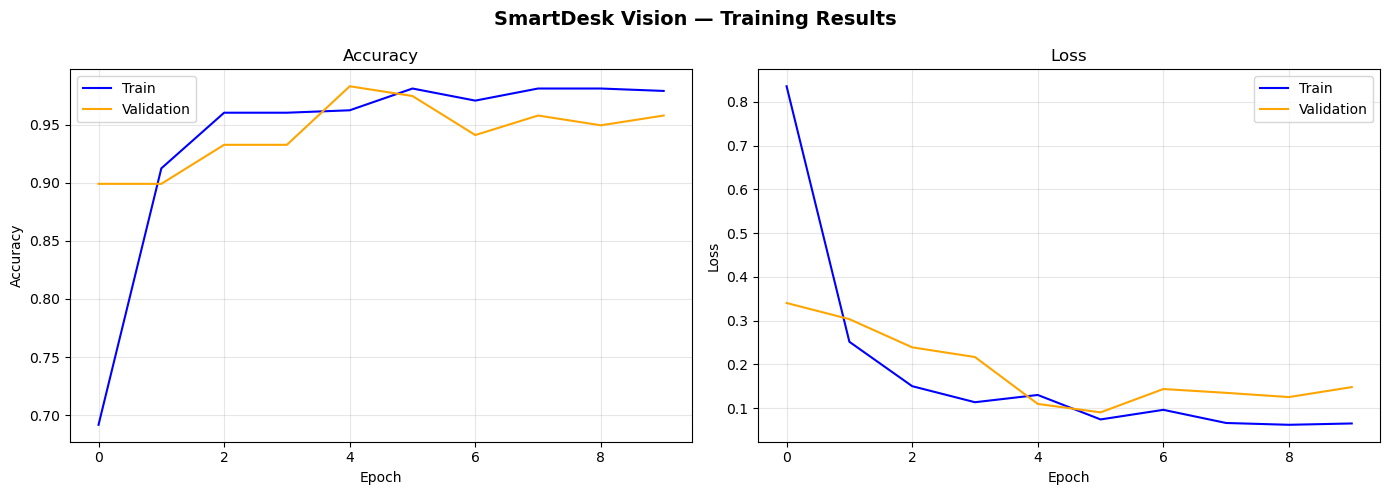

✅ Graph saved as training_results.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SmartDesk Vision — Training Results", fontsize=14, fontweight="bold")

axes[0].plot(history.history["accuracy"],     label="Train",      color="blue")
axes[0].plot(history.history["val_accuracy"], label="Validation", color="orange")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"],     label="Train",      color="blue")
axes[1].plot(history.history["val_loss"], label="Validation", color="orange")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graph saved as training_results.png")

In [14]:
class_indices = train_data.class_indices
class_names   = {str(v): k for k, v in class_indices.items()}

with open("class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)

val_loss, val_acc = model.evaluate(val_data, verbose=0)

print("="*40)
print("FINAL RESULTS")
print("="*40)
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Class names saved   : class_names.json")
print(f"Model saved         : model.h5")
print("="*40)
print("\nFiles for Member 2:")
print("  1. model.h5")
print("  2. class_names.json")
print("\n✅ Member 1 COMPLETE!")

FINAL RESULTS
Validation Accuracy : 97.48%
Validation Loss     : 0.1205
Class names saved   : class_names.json
Model saved         : model.h5

Files for Member 2:
  1. model.h5
  2. class_names.json

✅ Member 1 COMPLETE!


In [15]:
import os

files = os.listdir(".")
print("Files in your project folder:")
for f in files:
    print(f"  {f}")

Files in your project folder:
  .ipynb_checkpoints
  class_names.json
  dataset
  download_images.ipynb
  model.h5
  training_results.png
  train_model.ipynb
